# Analysis of Two Cointegrated Time Series

Here cointegration analysis is applied to two ETF funds. The first is the iShares Australia fund, EWA anf the iShares Canada func, EWC. Both economies are commodity based. The analysis assumes that the funds satisfy the error correction model,

$
\begin{align}
\Delta Y_t = \gamma \Delta X_t + \lambda \left( Y_{t-1} - \beta X_{t-1} \right) + \nu_t
\end{align}
\tag{1}
$

 where $X_t$ and $Y_t$ are $I(1)$ processes and $\nu_t \sim \text{Normal}(0, \sigma^2)$. The residual is defined by,

$
\begin{align}
\varepsilon_{t-1} = Y_{t-1} - \beta X_{t-1}
\end{align}
\tag{2}
$

where $\varepsilon_{t-1} \sim I(0)$. OLS is used to used to estimate $\beta$.

## Analysis Procedure

1. Use ADF tests to verify that time series are not $I(0)$.
2. Use regression on $Y_{t-1}$ and $X_{t-1}$ to evaluate $\beta$.
3. Use ADF test to verify that the residual, $\varepsilon_{t-1} \sim $I(0)$.
4. Use regression on Eq. (1) to evaluate $\gamma$ and $\lambda$. This is the Granger two step procedure.

In [123]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot
from pandas import DataFrame, read_csv

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.utils import extract_date_range
from lib.data import ecm, stats, adf, arima
from lib.plots import comparison, ecm_beta, curve
from lib.utils import create_ensemble

# Config Plot Style
pyplot.style.use(config.glyfish_style)

In [124]:
file_path = os.path.abspath('../../../data/algorithmic_trading/EWA.csv')
ewa_data = read_csv(file_path, index_col=0, parse_dates=True).sort_values(by='Date').dropna()
ewa_data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1996-03-18,10.125,10.125,10.000,10.000,3.283057,35200
1996-03-19,10.125,10.125,10.125,10.125,3.324095,500
1996-03-20,10.125,10.125,10.125,10.125,3.324095,500
1996-03-21,10.250,10.250,10.250,10.250,3.365134,37700
1996-03-22,10.250,10.250,10.250,10.250,3.365134,600


In [125]:
file_path = os.path.abspath('../../../data/algorithmic_trading/EWC.csv')
ewc_data = read_csv(file_path, index_col=0, parse_dates=True).sort_values(by='Date').dropna()
ewc_data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1996-03-18,10.3125,10.3125,10.3125,10.3125,4.601596,500
1996-03-19,10.3750,10.3750,10.3750,10.3750,4.629483,200
1996-03-20,10.3750,10.3750,10.3750,10.3750,4.629483,0
1996-03-21,10.3750,10.3750,10.3750,10.3750,4.629483,0
1996-03-22,10.3750,10.3750,10.3750,10.3750,4.629483,0


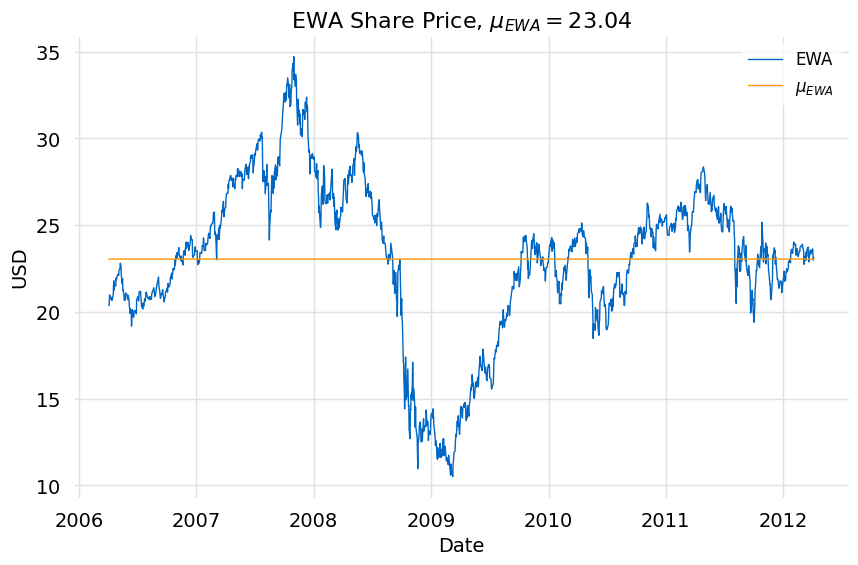

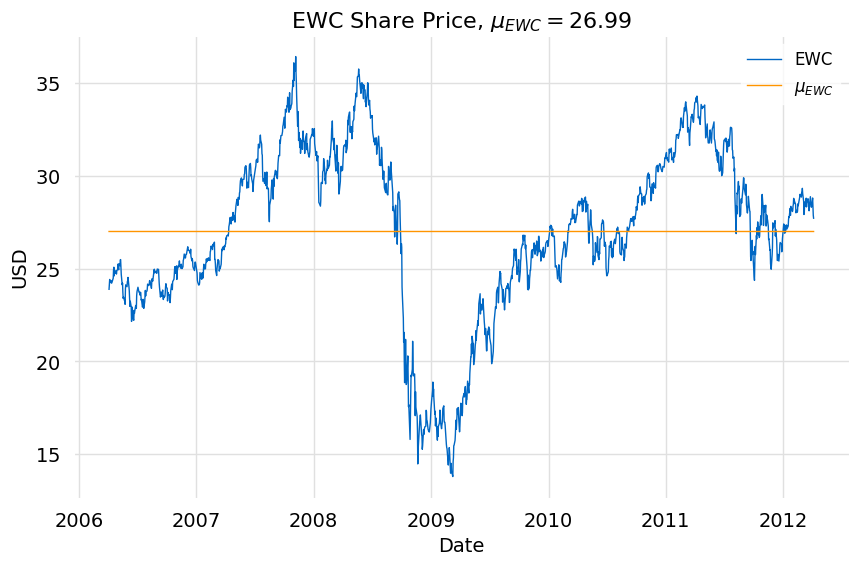

In [126]:
ewa_date, ewa_close = extract_date_range(ewa_data.index.to_numpy(), ewa_data['Close'].to_numpy(), '2006-04-04', '2012-04-09')
ewc_date, ewc_close = extract_date_range(ewc_data.index.to_numpy(), ewc_data['Close'].to_numpy(), '2006-04-04', '2012-04-09')

ewa_close_mean = numpy.full(ewa_close.shape, numpy.mean(ewa_close))
ewc_close_mean = numpy.full(ewc_close.shape, numpy.mean(ewc_close))

title = f"EWA Share Price, $\mu_{{EWA}} = {numpy.mean(ewa_close):.2f}$"
comparison([ewa_close, ewa_close_mean], [ewa_date, ewa_date], labels=['EWA', r"$\mu_{EWA}$"], title=title, xlabel='Date', ylabel='USD', lw=1)

title = f"EWC Share Price, $\mu_{{EWC}} = {numpy.mean(ewc_close):.2f}$"
comparison([ewc_close, ewc_close_mean], [ewc_date, ewc_date], labels=['EWC', r"$\mu_{EWC}$"], title=title, xlabel='Date', ylabel='USD', lw=1)

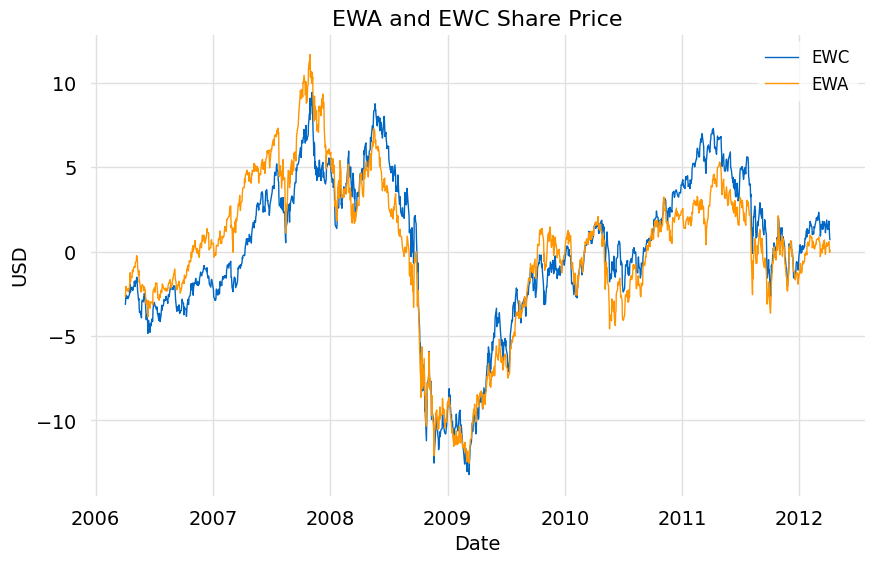

In [127]:
title = 'EWA and EWC Share Price'
ewc_close = ewc_close - numpy.mean(ewc_close)
ewa_close = ewa_close - numpy.mean(ewa_close)
comparison([ewc_close, ewa_close], [ewc_date, ewa_date], labels=['EWC', 'EWA'], title=title, xlabel='Date', ylabel='USD', lw=1)

## Verify Series are Not Stationary

In [128]:
result, result_model = adf.compute_adf_test(ewc_close)
result.summary()

╒════════════════╤══════════════╕
│ Test Statistic │   -1.98832   │
├────────────────┼──────────────┤
│ pvalue         │    0.0447284 │
├────────────────┼──────────────┤
│ Lags           │    0         │
├────────────────┼──────────────┤
│ Number Obs     │ 1513         │
╘════════════════╧══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56722 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94118 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61665 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [129]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "eab85dde-5218-49c7-ae3f-c9c943074137",
                "label": "$t$",
                "value": -1.9883184850558568
            },
            "pval": {
                "test_id": "eab85dde-5218-49c7-ae3f-c9c943074137",
                "label": "$p-value$",
                "value": 0.04472835080717785
            },
            "params": [],
            "sig": {
                "test_id": "eab85dde-5218-49c7-ae3f-c9c943074137",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "eab85dde-5218-49c7-ae3f-c9c943074137",
                "label": "$t_L$",
                "value": -2.567219310789199
            },
            "upper": null,
            "test_id": "eab85dde-5218-49c7-ae3f-c9c943074137"
        },
     

In [130]:
result, result_model = adf.compute_adf_test(ewa_close)
result.summary()

╒════════════════╤══════════════╕
│ Test Statistic │   -1.89574   │
├────────────────┼──────────────┤
│ pvalue         │    0.0553162 │
├────────────────┼──────────────┤
│ Lags           │    1         │
├────────────────┼──────────────┤
│ Number Obs     │ 1512         │
╘════════════════╧══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56722 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94118 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61665 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [131]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "516a3687-d8b5-4fc1-8c95-b52c453261aa",
                "label": "$t$",
                "value": -1.8957353913612784
            },
            "pval": {
                "test_id": "516a3687-d8b5-4fc1-8c95-b52c453261aa",
                "label": "$p-value$",
                "value": 0.05531624304170223
            },
            "params": [],
            "sig": {
                "test_id": "516a3687-d8b5-4fc1-8c95-b52c453261aa",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "516a3687-d8b5-4fc1-8c95-b52c453261aa",
                "label": "$t_L$",
                "value": -2.567220290217939
            },
            "upper": null,
            "test_id": "516a3687-d8b5-4fc1-8c95-b52c453261aa"
        },
     

## Estimate $\beta$ Assuming EWC $\sim$ EWA

In [132]:
result, beta_result_model = ecm.compute_beta_estimate(ewc_close, ewa_close)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     8493.
Date:                Sun, 17 Dec 2023   Prob (F-statistic):               0.00
Time:                        18:32:58   Log-Likelihood:                -3011.5
No. Observations:                1514   AIC:                             6027.
Df Residuals:                    1512   BIC:                             6038.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.546e-15      0.045    3.4e-14      1.000      -0.089       0.089
x1             0.9241      0.010     92.157      0.000       0.904       0.944
==============================================================================
Omnibus:                       85.024   Durbin-Watson:                   0.027
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               33.545
Skew:                           0.070   Prob(JB):                     5.20e-08
Kurtosis:                       2.284   Cond. No.                         4.54
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [133]:
print(beta_result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": 1.5457801938399625e-15,
      "err": 0.045483699441625516,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "3885588c-1646-4c8b-a4f3-560f3646eb52",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": 0.9241338353603675,
         "err": 0.010027865484350482,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "3885588c-1646-4c8b-a4f3-560f3646eb52",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.8488730866770358,
   "param_transforms": [
      {
         "param": {
            "est": 0.9241338353603675,
            "err": 0.010027865484350482,
            "est_label": "$\\hat{\\beta}$",
            "err_label": "$\\sigma_{\\hat{\\beta}}$",
            "row": 0,
            "column": 0,
            

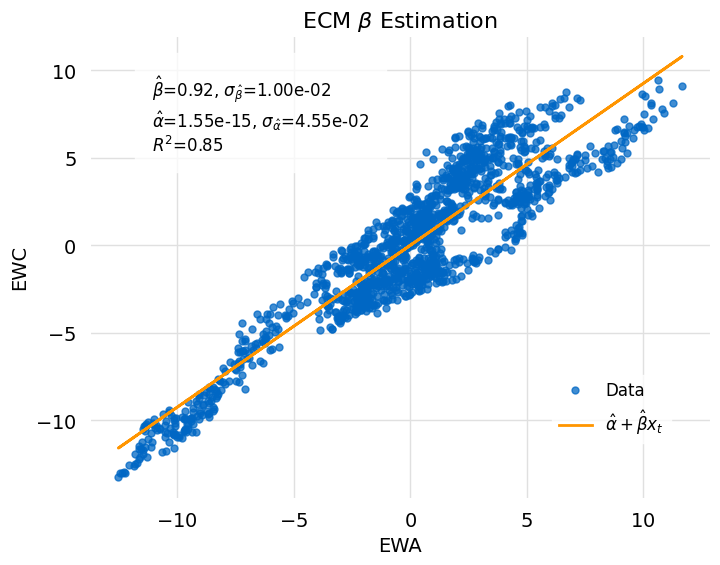

In [134]:
ecm_beta(ewc_close, beta_result_model, ewa_close, ylabel="EWC", xlabel="EWA")

### Verify that Residual is Stationary

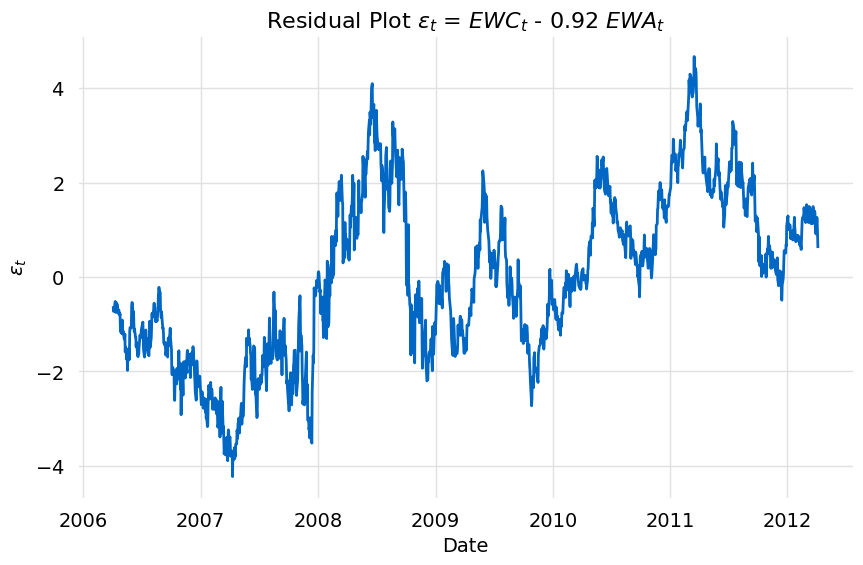

In [135]:
β = beta_result_model.params[0].est
εt = ewc_close - β * ewa_close
title = f"Residual Plot $\\varepsilon_t$ = $EWC_t$ - {β:.2f} $EWA_t$"
curve(εt, ewc_date, title=title, ylabel=r"$\varepsilon_t$", xlabel="Date")

In [136]:
result, result_model = adf.compute_adf_test(εt)
result.summary()

╒════════════════╤══════════════╕
│ Test Statistic │   -2.5447    │
├────────────────┼──────────────┤
│ pvalue         │    0.0105833 │
├────────────────┼──────────────┤
│ Lags           │    4         │
├────────────────┼──────────────┤
│ Number Obs     │ 1509         │
╘════════════════╧══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56722 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94118 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61665 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


## Estimate $\gamma$ and $\lambda$

In [137]:
result, gamma_lambda_result_model = ecm.compute_gamma_lambda_estimate(ewa_close, ewc_close, beta_result_model.params[0].est)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.627
Model:                            OLS   Adj. R-squared:                  0.627
Method:                 Least Squares   F-statistic:                     1271.
Date:                Sun, 17 Dec 2023   Prob (F-statistic):               0.00
Time:                        18:33:00   Log-Likelihood:                -308.15
No. Observations:                1513   AIC:                             622.3
Df Residuals:                    1510   BIC:                             638.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0003      0.008     -0.044      0.965      -0.015       0.015
x1             0.8534      0.017     50.410      0.000       0.820       0.887
x2            -0.0136      0.004     -3.131      0.002      -0.022      -0.005
==============================================================================
Omnibus:                       99.033   Durbin-Watson:                   2.361
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              370.058
Skew:                          -0.201   Prob(JB):                     4.39e-81
Kurtosis:                       5.389   Cond. No.                         3.91
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [138]:
print(gamma_lambda_result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -0.0003375767127831056,
      "err": 0.007633667152713485,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "949b596a-ef18-492a-b28a-1be65655314c",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": 0.853430515553868,
         "err": 0.016929864534501758,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "949b596a-ef18-492a-b28a-1be65655314c",
         "param_type": "OLS_PARAM"
      },
      {
         "est": -0.013563557822506869,
         "err": 0.004331835546554314,
         "est_label": "$\\alpha_2$",
         "err_label": "$\\sigma_{\\alpha_2}$",
         "row": 0,
         "column": 2,
         "order": 0,
         "est_id": "949b596a-ef18-492a-b28a-1be65655314c",
         "param_type": "OLS_PARAM"


## Estimate $\beta$ Assuming EWA $\sim$ EWC

In [139]:
result, beta_result_model = ecm.compute_beta_estimate(ewa_close, ewc_close)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     8493.
Date:                Sun, 17 Dec 2023   Prob (F-statistic):               0.00
Time:                        18:33:00   Log-Likelihood:                -3007.0
No. Observations:                1514   AIC:                             6018.
Df Residuals:                    1512   BIC:                             6029.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.679e-15      0.045   8.11e-14      1.000      -0.089       0.089
x1             0.9186      0.010     92.157      0.000       0.899       0.938
==============================================================================
Omnibus:                       77.131   Durbin-Watson:                   0.029
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               73.312
Skew:                           0.487   Prob(JB):                     1.20e-16
Kurtosis:                       2.537   Cond. No.                         4.55
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [140]:
print(beta_result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": 3.678542936572248e-15,
      "err": 0.04534634542667218,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "75d5e79f-be7a-4831-823f-23841249e2c0",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": 0.9185607692266918,
         "err": 0.00996739160558369,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "75d5e79f-be7a-4831-823f-23841249e2c0",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.8488730866770353,
   "param_transforms": [
      {
         "param": {
            "est": 0.9185607692266918,
            "err": 0.00996739160558369,
            "est_label": "$\\hat{\\beta}$",
            "err_label": "$\\sigma_{\\hat{\\beta}}$",
            "row": 0,
            "column": 0,
            "ord

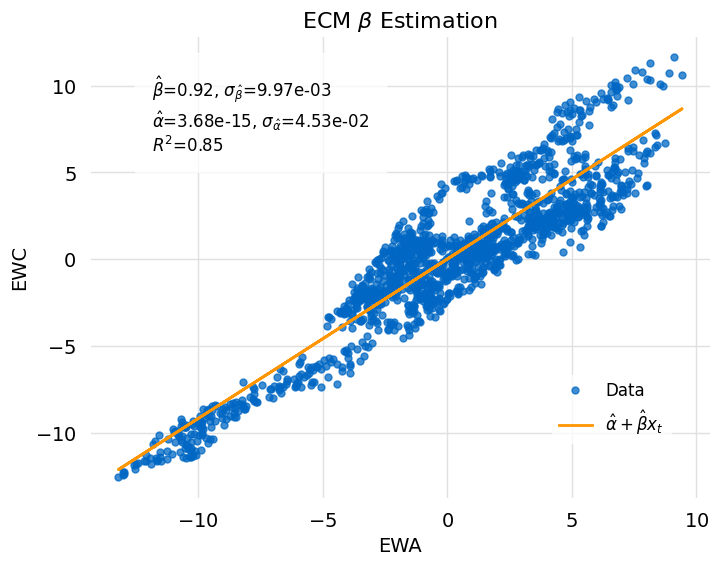

In [141]:
ecm_beta(ewa_close, beta_result_model, ewc_close, ylabel="EWC", xlabel="EWA")

### Verify that Residual is Stationary

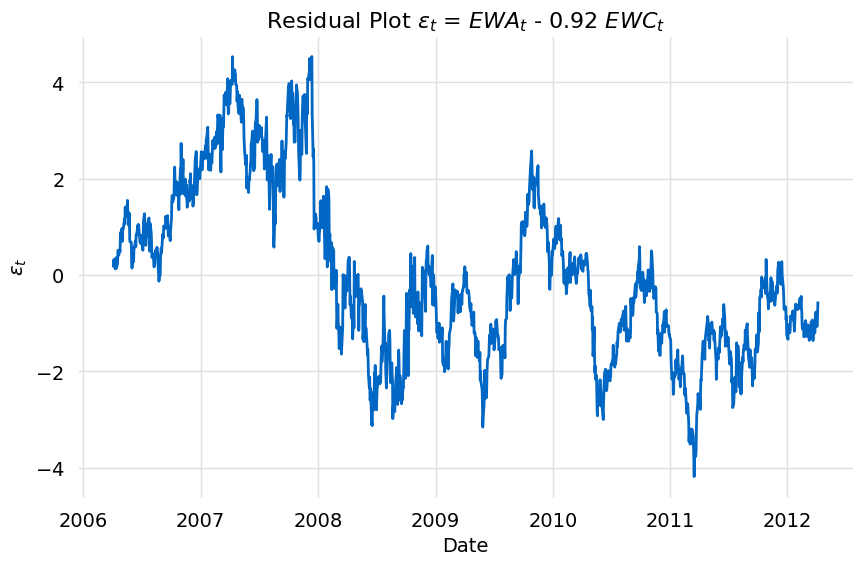

In [142]:
β = beta_result_model.params[0].est
εt = ewa_close - β * ewc_close
title = f"Residual Plot $\\varepsilon_t$ = $EWA_t$ - {β:.2f} $EWC_t$"
curve(εt, ewc_date, title=title, ylabel=r"$\varepsilon_t$", xlabel="Date")

In [143]:
result, result_model = adf.compute_adf_test(εt)
result.summary()

╒════════════════╤══════════════╕
│ Test Statistic │   -2.47711   │
├────────────────┼──────────────┤
│ pvalue         │    0.0127952 │
├────────────────┼──────────────┤
│ Lags           │    4         │
├────────────────┼──────────────┤
│ Number Obs     │ 1509         │
╘════════════════╧══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56722 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94118 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61665 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


## Estimate $\gamma$ and $\lambda$

In [144]:
result, gamma_lambda_result_model = ecm.compute_gamma_lambda_estimate(ewa_close, ewc_close, beta_result_model.params[0].est)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.627
Model:                            OLS   Adj. R-squared:                  0.627
Method:                 Least Squares   F-statistic:                     1271.
Date:                Sun, 17 Dec 2023   Prob (F-statistic):               0.00
Time:                        18:33:02   Log-Likelihood:                -308.11
No. Observations:                1513   AIC:                             622.2
Df Residuals:                    1510   BIC:                             638.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0003      0.008     -0.044      0.965      -0.015       0.015
x1             0.8534      0.017     50.411      0.000       0.820       0.887
x2            -0.0136      0.004     -3.143      0.002      -0.022      -0.005
==============================================================================
Omnibus:                       99.051   Durbin-Watson:                   2.361
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              370.326
Skew:                          -0.201   Prob(JB):                     3.84e-81
Kurtosis:                       5.390   Cond. No.                         3.91
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [145]:
print(gamma_lambda_result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -0.00033751680044400643,
      "err": 0.007633477670681288,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "83155e04-9971-42fd-8f87-ca99e36ee649",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": 0.8534006737532339,
         "err": 0.016928894115015695,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "83155e04-9971-42fd-8f87-ca99e36ee649",
         "param_type": "OLS_PARAM"
      },
      {
         "est": -0.013616270623805727,
         "err": 0.004332032934065491,
         "est_label": "$\\alpha_2$",
         "err_label": "$\\sigma_{\\alpha_2}$",
         "row": 0,
         "column": 2,
         "order": 0,
         "est_id": "83155e04-9971-42fd-8f87-ca99e36ee649",
         "param_type": "OLS_PARAM